In [1]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import missingno as msno

In [2]:
# divorces dataset
df = pd.read_csv("dataset/divorces_2000-2015_translated.csv")
df.columns

Index(['Divorce_date', 'Type_of_divorce', 'Nationality_partner_man',
       'DOB_partner_man', 'Place_of_birth_partner_man',
       'Birth_municipality_of_partner_man', 'Birth_federal_partner_man',
       'Birth_country_partner_man', 'Age_partner_man',
       'Residence_municipality_partner_man', 'Residence_federal_partner_man',
       'Residence_country_partner_man', 'Monthly_income_partner_man_peso',
       'Occupation_partner_man', 'Place_of_residence_partner_man',
       'Nationality_partner_woman', 'DOB_partner_woman',
       'DOB_registration_date_partner_woman', 'Place_of_birth_partner_woman',
       'Birth_municipality_of_partner_woman', 'Birth_federal_partner_woman',
       'Birth_country_partner_woman', 'Age_partner_woman',
       'Place_of_residence_partner_woman',
       'Residence_municipality_partner_woman',
       'Residence_federal_partner_woman', 'Residence_country_partner_woman',
       'Occupation_partner_woman', 'Monthly_income_partner_woman_peso',
       'Date_of_m

Important columns

1. Divorce_date
2. Type_of_divorce
3. DOB_partner_man
4. DOB_partner_woman
5. Marriage Duration
6. Marriage Duration Months


In [3]:
divorce = df[["Divorce_date", "DOB_partner_man", "DOB_partner_woman", "Type_of_divorce", "Marriage_duration", "Marriage_duration_months"]]
divorce_subset = divorce.dropna()
divorce_subset

,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months
8,1/2/08,2/12/76,3/1/80,Voluntario,1.0,7.0
9,1/2/08,17/11/76,13/3/77,Voluntario,7.0,11.0
13,1/2/11,31/1/73,5/11/70,Necesario,12.0,3.0
20,1/3/05,3/10/71,30/3/72,Necesario,11.0,8.0
28,1/3/11,9/3/84,26/3/88,Necesario,3.0,1.0
...,...,...,...,...,...,...
4906,31/10/02,18/8/51,1/6/66,Voluntario,6.0,3.0
4907,31/10/02,27/10/51,26/7/67,Voluntario,18.0,10.0
4908,31/10/03,11/8/76,6/11/74,Voluntario,3.0,8.0
4909,31/10/03,15/12/66,15/7/74,Voluntario,4.0,10.0


<Axes: >

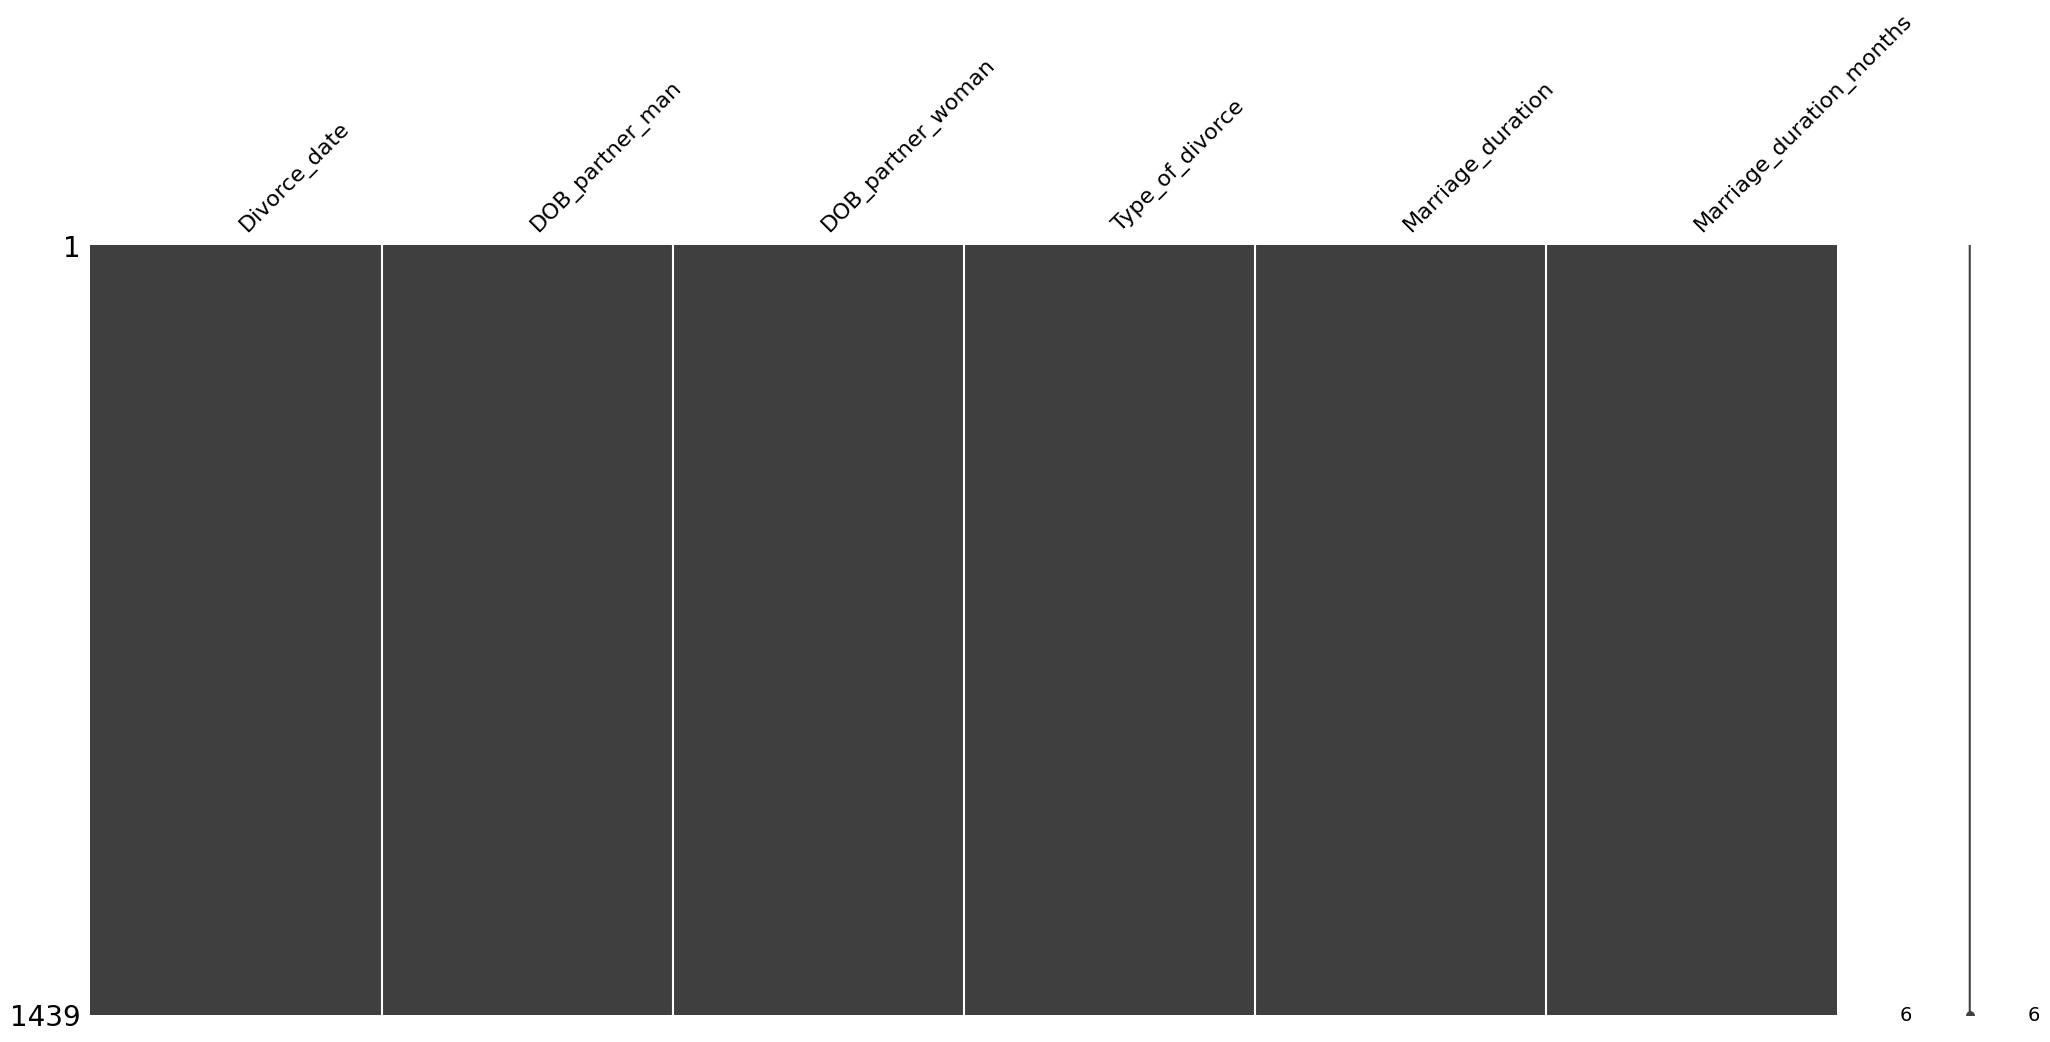

In [4]:
msno.matrix(divorce_subset)

In [5]:
divorce_subset["DOB_partner_man"] = pd.to_datetime(divorce_subset["DOB_partner_man"], format="%d/%m/%y")
divorce_subset["DOB_partner_woman"] = pd.to_datetime(divorce_subset["DOB_partner_woman"], format="%d/%m/%y")

/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/2724582122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divorce_subset["DOB_partner_man"] = pd.to_datetime(divorce_subset["DOB_partner_man"], format="%d/%m/%y")
/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/2724582122.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divorce_subset["DOB_partner_woman"] = pd.to_datetime(divorce_subset["DOB_partner_woman"], format="%d/%m/%y")


In [6]:
def get_zodiac_sign(date):
    day = date.day
    month = date.month

    if (month == 3 and day >= 21) or (month == 4 and day <= 19):
        return "Aries"
    elif (month == 4 and day >= 20) or (month == 5 and day <= 20):
        return "Taurus"
    elif (month == 5 and day >= 21) or (month == 6 and day <= 20):
        return "Gemini"
    elif (month == 6 and day >= 21) or (month == 7 and day <= 22):
        return "Cancer"
    elif (month == 7 and day >= 23) or (month == 8 and day <= 22):
        return "Leo"
    elif (month == 8 and day >= 23) or (month == 9 and day <= 22):
        return "Virgo"
    elif (month == 9 and day >= 23) or (month == 10 and day <= 22):
        return "Libra"
    elif (month == 10 and day >= 23) or (month == 11 and day <= 21):
        return "Scorpio"
    elif (month == 11 and day >= 22) or (month == 12 and day <= 21):
        return "Sagittarius"
    elif (month == 12 and day >= 22) or (month == 1 and day <= 19):
        return "Capricorn"
    elif (month == 1 and day >= 20) or (month == 2 and day <= 18):
        return "Aquarius"
    else:
        return "Pisces"

In [7]:
divorce_subset["zodiac_sign_man"] = divorce_subset["DOB_partner_man"].apply(get_zodiac_sign)
divorce_subset

/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/927479015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divorce_subset["zodiac_sign_man"] = divorce_subset["DOB_partner_man"].apply(get_zodiac_sign)


,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months,zodiac_sign_man
8,1/2/08,1976-12-02,1980-01-03,Voluntario,1.0,7.0,Sagittarius
9,1/2/08,1976-11-17,1977-03-13,Voluntario,7.0,11.0,Scorpio
13,1/2/11,1973-01-31,1970-11-05,Necesario,12.0,3.0,Aquarius
20,1/3/05,1971-10-03,1972-03-30,Necesario,11.0,8.0,Libra
28,1/3/11,1984-03-09,1988-03-26,Necesario,3.0,1.0,Pisces
...,...,...,...,...,...,...,...
4906,31/10/02,2051-08-18,2066-06-01,Voluntario,6.0,3.0,Leo
4907,31/10/02,2051-10-27,2067-07-26,Voluntario,18.0,10.0,Scorpio
4908,31/10/03,1976-08-11,1974-11-06,Voluntario,3.0,8.0,Leo
4909,31/10/03,2066-12-15,1974-07-15,Voluntario,4.0,10.0,Sagittarius


In [8]:
divorce_subset["zodiac_sign_woman"] = divorce_subset["DOB_partner_woman"].apply(get_zodiac_sign)
divorce_subset

/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/2302671698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divorce_subset["zodiac_sign_woman"] = divorce_subset["DOB_partner_woman"].apply(get_zodiac_sign)


,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months,zodiac_sign_man,zodiac_sign_woman
8,1/2/08,1976-12-02,1980-01-03,Voluntario,1.0,7.0,Sagittarius,Capricorn
9,1/2/08,1976-11-17,1977-03-13,Voluntario,7.0,11.0,Scorpio,Pisces
13,1/2/11,1973-01-31,1970-11-05,Necesario,12.0,3.0,Aquarius,Scorpio
20,1/3/05,1971-10-03,1972-03-30,Necesario,11.0,8.0,Libra,Aries
28,1/3/11,1984-03-09,1988-03-26,Necesario,3.0,1.0,Pisces,Aries
...,...,...,...,...,...,...,...,...
4906,31/10/02,2051-08-18,2066-06-01,Voluntario,6.0,3.0,Leo,Gemini
4907,31/10/02,2051-10-27,2067-07-26,Voluntario,18.0,10.0,Scorpio,Leo
4908,31/10/03,1976-08-11,1974-11-06,Voluntario,3.0,8.0,Leo,Scorpio
4909,31/10/03,2066-12-15,1974-07-15,Voluntario,4.0,10.0,Sagittarius,Cancer


In [9]:
divorce_subset["Type_of_divorce"].value_counts()

Type_of_divorce
Voluntario    1232
Necesario      207
Name: count, dtype: int64

In [10]:
# Translate divorce types from Spanish to English 
divorce_subset["Type_of_divorce"] = divorce_subset["Type_of_divorce"].replace({
    "Voluntario": "Volunteer",
    "Necesario": "Necessary"
})

divorce_subset["Type_of_divorce"].value_counts()
divorce_subset

/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/3515507963.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divorce_subset["Type_of_divorce"] = divorce_subset["Type_of_divorce"].replace({


,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months,zodiac_sign_man,zodiac_sign_woman
8,1/2/08,1976-12-02,1980-01-03,Volunteer,1.0,7.0,Sagittarius,Capricorn
9,1/2/08,1976-11-17,1977-03-13,Volunteer,7.0,11.0,Scorpio,Pisces
13,1/2/11,1973-01-31,1970-11-05,Necessary,12.0,3.0,Aquarius,Scorpio
20,1/3/05,1971-10-03,1972-03-30,Necessary,11.0,8.0,Libra,Aries
28,1/3/11,1984-03-09,1988-03-26,Necessary,3.0,1.0,Pisces,Aries
...,...,...,...,...,...,...,...,...
4906,31/10/02,2051-08-18,2066-06-01,Volunteer,6.0,3.0,Leo,Gemini
4907,31/10/02,2051-10-27,2067-07-26,Volunteer,18.0,10.0,Scorpio,Leo
4908,31/10/03,1976-08-11,1974-11-06,Volunteer,3.0,8.0,Leo,Scorpio
4909,31/10/03,2066-12-15,1974-07-15,Volunteer,4.0,10.0,Sagittarius,Cancer


In [11]:
# Create a combined column for zodiac pairs
divorce_subset["zodiac_couple"] = divorce_subset["zodiac_sign_man"] + " + " + divorce_subset["zodiac_sign_woman"]
divorce_subset

/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/889897164.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divorce_subset["zodiac_couple"] = divorce_subset["zodiac_sign_man"] + " + " + divorce_subset["zodiac_sign_woman"]


,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months,zodiac_sign_man,zodiac_sign_woman,zodiac_couple
8,1/2/08,1976-12-02,1980-01-03,Volunteer,1.0,7.0,Sagittarius,Capricorn,Sagittarius + Capricorn
9,1/2/08,1976-11-17,1977-03-13,Volunteer,7.0,11.0,Scorpio,Pisces,Scorpio + Pisces
13,1/2/11,1973-01-31,1970-11-05,Necessary,12.0,3.0,Aquarius,Scorpio,Aquarius + Scorpio
20,1/3/05,1971-10-03,1972-03-30,Necessary,11.0,8.0,Libra,Aries,Libra + Aries
28,1/3/11,1984-03-09,1988-03-26,Necessary,3.0,1.0,Pisces,Aries,Pisces + Aries
...,...,...,...,...,...,...,...,...,...
4906,31/10/02,2051-08-18,2066-06-01,Volunteer,6.0,3.0,Leo,Gemini,Leo + Gemini
4907,31/10/02,2051-10-27,2067-07-26,Volunteer,18.0,10.0,Scorpio,Leo,Scorpio + Leo
4908,31/10/03,1976-08-11,1974-11-06,Volunteer,3.0,8.0,Leo,Scorpio,Leo + Scorpio
4909,31/10/03,2066-12-15,1974-07-15,Volunteer,4.0,10.0,Sagittarius,Cancer,Sagittarius + Cancer


In [12]:
zodiac_couples = divorce_subset["zodiac_couple"].value_counts()
zodiac_couples.head(20)

#MAYBE Visualization on this

zodiac_couple
Taurus + Gemini            18
Scorpio + Virgo            18
Libra + Libra              17
Aquarius + Gemini          17
Scorpio + Pisces           16
Libra + Cancer             16
Virgo + Virgo              16
Leo + Aquarius             16
Virgo + Pisces             15
Cancer + Aries             15
Capricorn + Aquarius       15
Pisces + Libra             15
Cancer + Aquarius          14
Taurus + Aries             14
Pisces + Leo               14
Scorpio + Taurus           14
Gemini + Taurus            14
Pisces + Pisces            14
Scorpio + Scorpio          13
Capricorn + Sagittarius    13
Name: count, dtype: int64

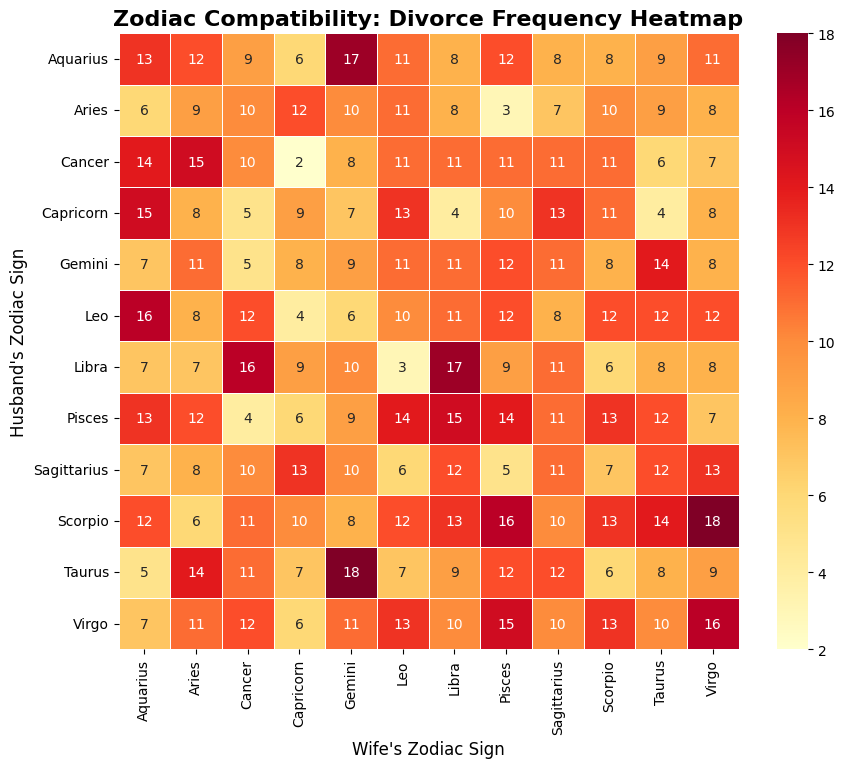

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Which zodiac combinations are the most dangerous? 
#Visualizes the frequency of divorces across all possible zodiac pairs 
#Darker colors indicate a higher number of divorces for that specific match

plt.figure(figsize=(10, 8))

#Create a crosstab for the heatmap
zodiac_crosstab = pd.crosstab(divorce_subset['zodiac_sign_man'], divorce_subset['zodiac_sign_woman'])

#Heatmap
sns.heatmap(zodiac_crosstab, annot=True, fmt='d', cmap='YlOrRd', linewidths=.5)

plt.title('Zodiac Compatibility: Divorce Frequency Heatmap', fontsize=16, fontweight='bold')
plt.xlabel("Wife's Zodiac Sign", fontsize=12)
plt.ylabel("Husband's Zodiac Sign", fontsize=12)

plt.show()

/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/725169624.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_couples.values, y=top_couples.index, palette='viridis')


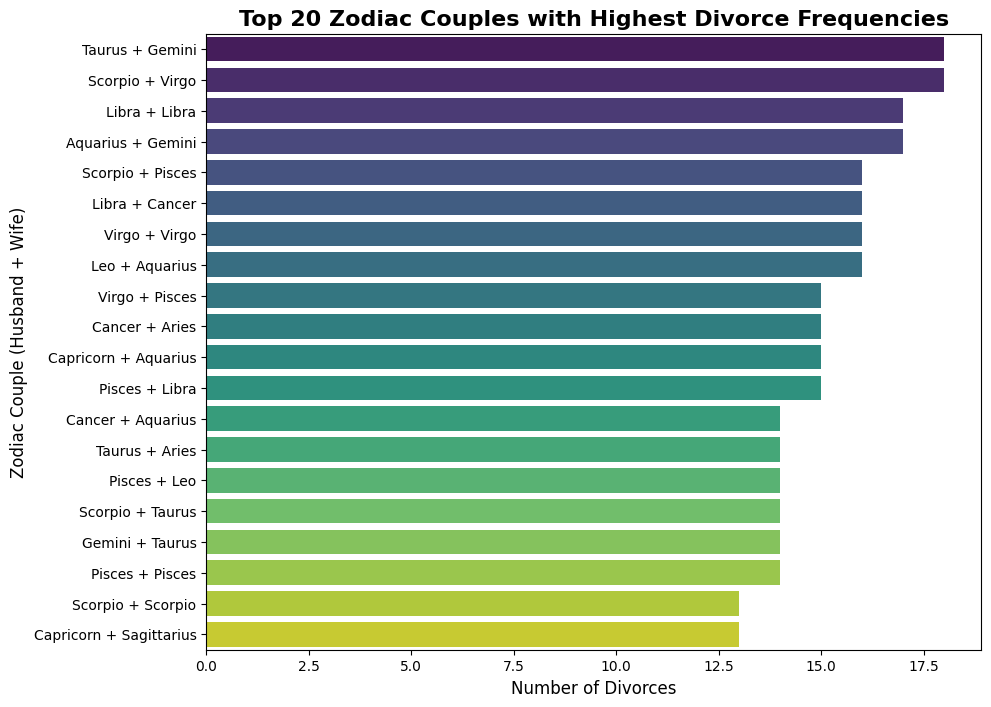

In [14]:
plt.figure(figsize=(10, 8))

#Top 20 divorced couples 
top_couples = divorce_subset['zodiac_couple'].value_counts().head(20)

#Bar plot
sns.barplot(x=top_couples.values, y=top_couples.index, palette='viridis')

plt.title('Top 20 Zodiac Couples with Highest Divorce Frequencies', fontsize=16, fontweight='bold')
plt.xlabel('Number of Divorces', fontsize=12)
plt.ylabel('Zodiac Couple (Husband + Wife)', fontsize=12)

plt.show()

/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/3139957487.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=divorce_subset, y='zodiac_sign_man',
/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/3139957487.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=divorce_subset, y='zodiac_sign_woman',


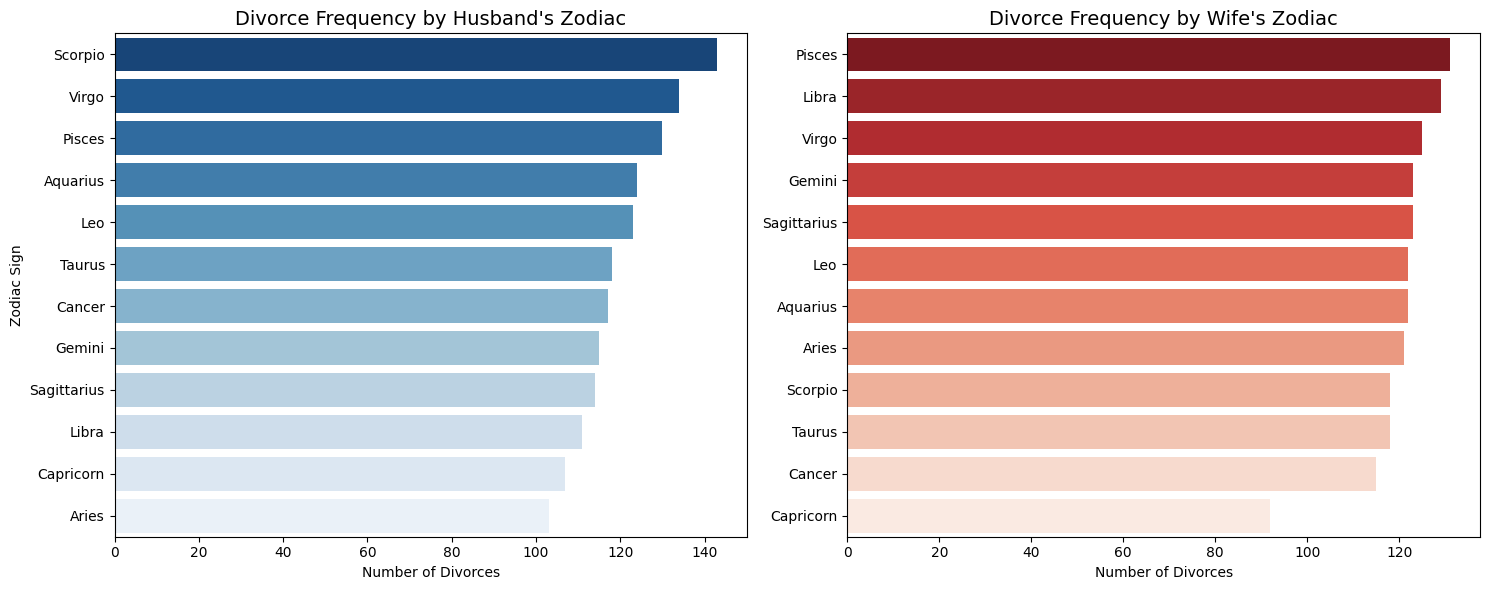

In [15]:
#2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#1. Plot divorce frequency by husband's zodiac sign
sns.countplot(data=divorce_subset, y='zodiac_sign_man', 
              order=divorce_subset['zodiac_sign_man'].value_counts().index, 
              palette='Blues_r', ax=axes[0])
axes[0].set_title("Divorce Frequency by Husband's Zodiac", fontsize=14)
axes[0].set_xlabel("Number of Divorces")
axes[0].set_ylabel("Zodiac Sign")

#2. Plot divorce frequency by wife's zodiac sign
sns.countplot(data=divorce_subset, y='zodiac_sign_woman', 
              order=divorce_subset['zodiac_sign_woman'].value_counts().index, 
              palette='Reds_r', ax=axes[1])
axes[1].set_title("Divorce Frequency by Wife's Zodiac", fontsize=14)
axes[1].set_xlabel("Number of Divorces")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

/var/folders/c_/hhmlbpsn3g9631b_828lljym0000gn/T/ipykernel_59031/2336773383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=divorce_subset, x='Marriage_duration', y='zodiac_sign_man',


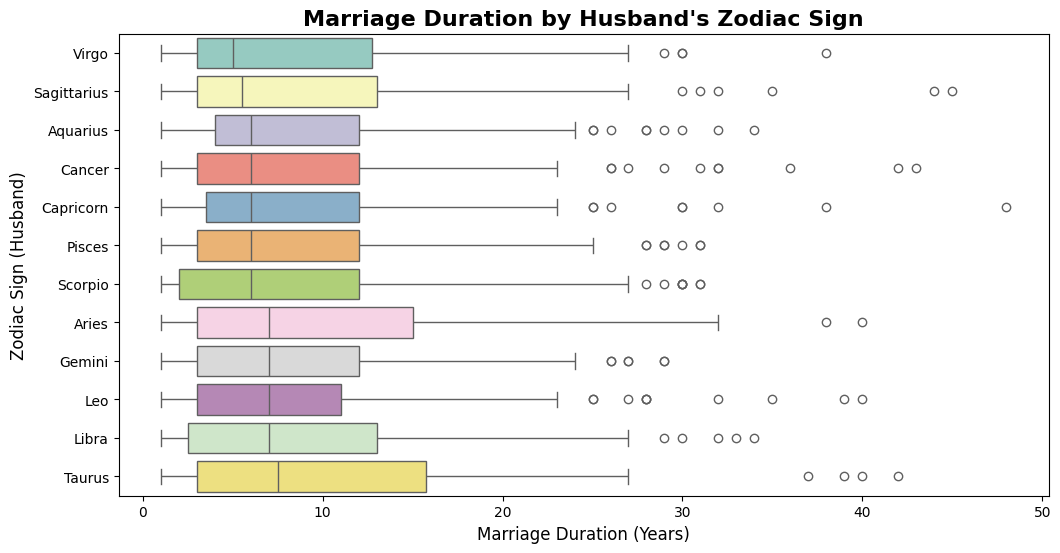

In [16]:
plt.figure(figsize=(12, 6))

#Calculate the median marriage duration for each zodiac sign and sort them
order = divorce_subset.groupby('zodiac_sign_man')['Marriage_duration'].median().sort_values().index

#Boxplot to show the distribution of marriage duration
sns.boxplot(data=divorce_subset, x='Marriage_duration', y='zodiac_sign_man', 
            order=order, palette='Set3')

#Titles and labels
plt.title("Marriage Duration by Husband's Zodiac Sign", fontsize=16, fontweight='bold')
plt.xlabel("Marriage Duration (Years)", fontsize=12)
plt.ylabel("Zodiac Sign (Husband)", fontsize=12)

plt.show()

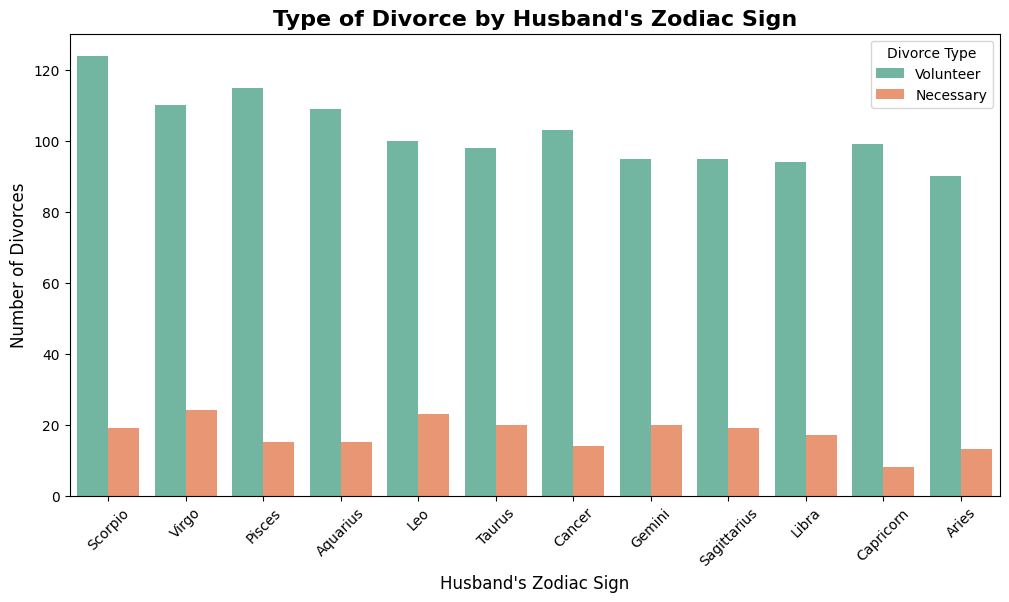

In [17]:
plt.figure(figsize=(12, 6))

#Grouped bar chart to visualize divorce types by zodiac sign
sns.countplot(data=divorce_subset, x='zodiac_sign_man', hue='Type_of_divorce', 
              order=divorce_subset['zodiac_sign_man'].value_counts().index,
              palette='Set2')

#Titles and labels
plt.title("Type of Divorce by Husband's Zodiac Sign", fontsize=16, fontweight='bold')
plt.xlabel("Husband's Zodiac Sign", fontsize=12)
plt.ylabel("Number of Divorces", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Divorce Type")

plt.show()